# ECF4 - Fake News

In [78]:
# Imports
import warnings
from pathlib import Path
from collections import Counter
from copy import deepcopy
import re
import time
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import joblib

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
keras.utils.set_random_seed(RANDOM_STATE)
tf.config.experimental.enable_op_determinism()


def ensure_stopwords_downloaded():
    try:
        nltk.data.find("corpora/stopwords")
    except LookupError:
        nltk.download("stopwords")


ensure_stopwords_downloaded()

In [35]:
# Chemins
PROJECT_DIR = Path("../").resolve()
DATA_DIR = PROJECT_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
DATA_FILE = DATA_DIR / "fake_or_real_news.csv"
DATA_CLEAN_FILE = DATA_DIR / "titles_clean.csv"

FIGURE_DIR = PROJECT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

MODELS_DIR = PROJECT_DIR / "models"
TF_IDF_VECTORIZER_FILE = MODELS_DIR / "tf_idf_vectorizer.pkl"
MODEL_DENSE_FILE = MODELS_DIR / "model_dense.keras"
MODEL_BIDIRECTIONAL_LSTM_FILE = MODELS_DIR / "model_bidirectional_lstm.keras"

In [36]:
# Configurations des graphiques
sns.set_theme(
    style="whitegrid",
    palette="colorblind",
    context="notebook",
)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.family": "Arial",
        "font.size": 12,
        "axes.titlesize": 15,
        "axes.titleweight": "bold",
        "axes.labelsize": 13,
        "axes.labelweight": "medium",
        "axes.edgecolor": "black",
        "axes.linewidth": 1.2,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "lines.linewidth": 2.2,
        "lines.markersize": 7,
        "legend.fontsize": 11,
        "legend.frameon": True,
        "legend.framealpha": 0.95,
        "grid.linestyle": ":",
        "grid.linewidth": 0.8,
        "grid.alpha": 0.6,
    }
)

PALETTE = sns.color_palette("colorblind")

## Partie 1 — Chargement et exploration

### 1.1 Chargement et constitution du corpus de titres

In [37]:
def normalize_text(text):
    if text is None:
        return ""

    text = unicodedata.normalize("NFKC", str(text))
    text = re.sub(r"[^\x00-\x7F]+", " ", text)
    text = text.encode("utf-8", "ignore").decode("utf-8")
    return text


def convert_label(label_str: str) -> int:
    if label_str.lower() == "fake":
        return 0
    elif label_str.lower() == "real":
        return 1
    else:
        return None


def load_titles(filepath: Path) -> pd.DataFrame:
    if not filepath.exists():
        raise FileNotFoundError(f"Fichier introuvable: path={str(filepath)}")

    df = pd.read_csv(filepath, encoding="utf-8", encoding_errors="ignore")
    length_df = len(df)
    print(
        f"Dimensions du jeu de données chargé : {df.shape[0]} lignes et {df.shape[1]} colonnes"
    )

    df = df[["title", "label"]]
    df = df.rename(columns={"title": "text"})
    df["label"] = df["label"].apply(convert_label)
    df["text"] = df["text"].apply(normalize_text)
    df = df.dropna()
    mask = (
        (df["text"].str.strip() != "")
        & (df["text"].str.strip().str.lower() != "null")
        & (df["text"].str.strip().str.lower() != "none")
    )
    df = df[mask]
    length_df_processed = len(df)
    print(
        f"Dimensions du jeu de données après traitement : {df.shape[0]} lignes et {df.shape[1]} colonnes"
    )
    print(f"Nombre de lignes supprimées : {length_df - length_df_processed}")

    df.to_csv(DATA_CLEAN_FILE, index=False)
    return df


df = load_titles(DATA_FILE)
df.head()

Dimensions du jeu de données chargé : 6335 lignes et 4 colonnes
Dimensions du jeu de données après traitement : 6335 lignes et 2 colonnes
Nombre de lignes supprimées : 0


,text,label
0,You Can Smell Hillary s Fear,0
1,Watch The Exact Moment Paul Ryan Committed Pol...,0
2,Kerry to go to Paris in gesture of sympathy,1
3,Bernie supporters on Twitter erupt in anger ag...,0
4,The Battle of New York: Why This Primary Matters,1


### 1.2 Analyse exploratoire

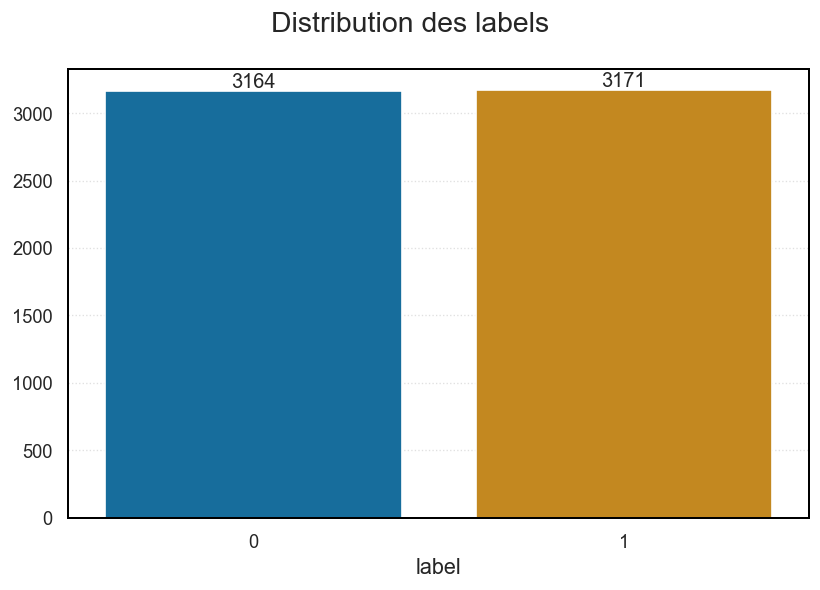

In [38]:
def create_barplot(
    ax: plt.Axes, df: pd.DataFrame, column: str, rotation: int = 0
) -> None:
    value_counts = df[column].value_counts()

    barplot = sns.barplot(
        x=value_counts.index,
        y=value_counts.values,
        palette=PALETTE,
        hue=value_counts.index,
        legend=False,
        ax=ax,
    )

    for container in barplot.containers:
        barplot.bar_label(container)

    if rotation:
        ax.tick_params(axis="x", rotation=rotation)


fig, ax = plt.subplots(1, 1, figsize=(7, 5))

fig.suptitle("Distribution des labels", fontsize=17)

create_barplot(ax=ax, df=df, column="label", rotation=0)

plt.tight_layout()
plt.savefig((FIGURE_DIR / "01_label_distrubution.png").as_posix())
plt.show()

* Les classes sont équilibrée, aucune stratégie de rééquilibrage n'est à prévoir.
* Si les classes avaient été déséquilibrées, on aurait pu mettre en place une stratégie d'oversampling consistant à ajouter des données dans la classe minoritaire. Ces nouvelles données pouvant être artificielles ou une duplication des données existantes. Un autre stratégie possible consiste à pondérer la classes minoritaire avec un poid plus important lors de la phase d'entraînement d'un modèle de sorte qu'un classement érroné d'un classe minoritaire soit plus lourdement pénalisé.

In [39]:
df_eda = df.copy()
df_eda["tokens"] = df_eda["text"].str.split()
df_eda["length"] = df_eda["tokens"].apply(lambda list_tokens: len(list_tokens))

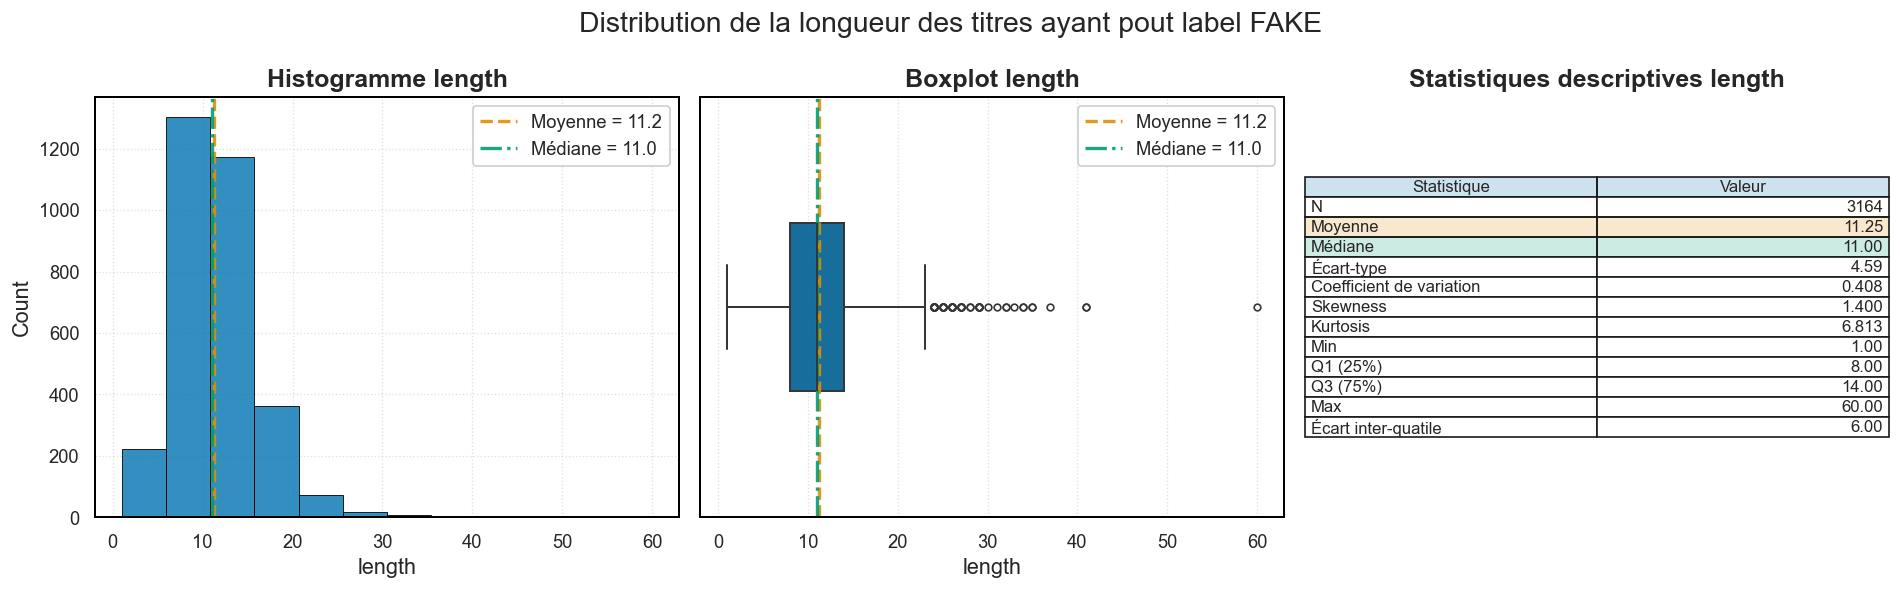

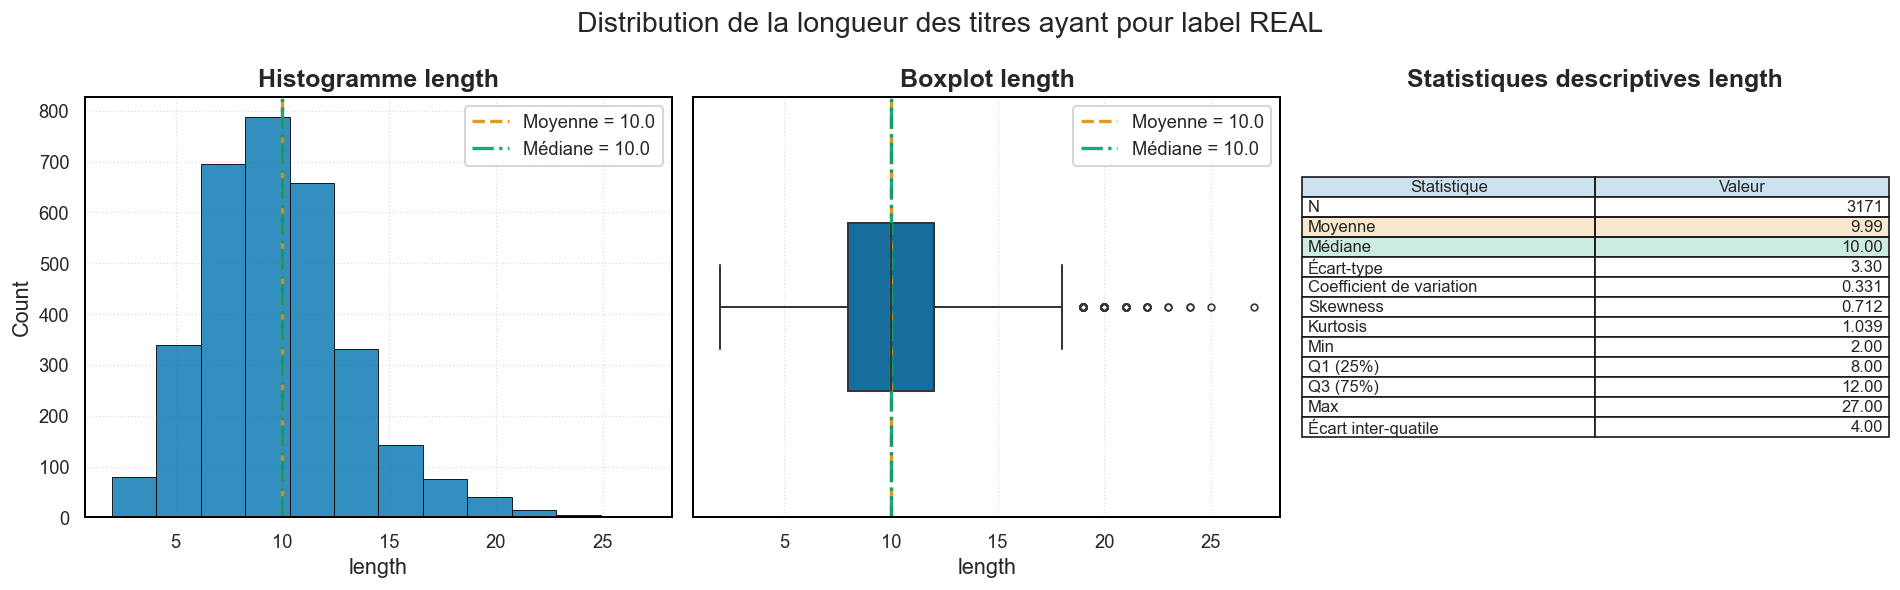

In [40]:
def create_histplot(ax: plt.Axes, df: pd.DataFrame, column: str) -> None:
    values = df[column].dropna()

    sns.histplot(
        x=values,
        bins=int(1 + np.log2(len(values))),
        color=PALETTE[0],
        edgecolor="black",
        linewidth=0.5,
        alpha=0.8,
        ax=ax,
    )

    mean_column = values.mean()
    median_column = values.median()

    ax.axvline(
        mean_column,
        color=PALETTE[1],
        linestyle="--",
        linewidth=2,
        alpha=0.9,
        label=f"Moyenne = {mean_column:.1f}",
    )

    ax.axvline(
        median_column,
        color=PALETTE[2],
        linestyle="-.",
        linewidth=2,
        alpha=0.9,
        label=f"Médiane = {median_column:.1f}",
    )

    ax.set_title(f"Histogramme {column}")
    ax.legend(frameon=True)


def create_boxplot(ax: plt.Axes, df: pd.DataFrame, column: str) -> None:
    values = df[column].dropna()

    sns.boxplot(
        x=values,
        ax=ax,
        color=PALETTE[0],
        width=0.4,
        fliersize=4,
        linewidth=1.2,
    )

    mean_val = values.mean()
    median_val = values.median()

    ax.axvline(
        mean_val,
        color=PALETTE[1],
        linestyle="--",
        linewidth=2,
        alpha=0.9,
        label=f"Moyenne = {mean_val:.1f}",
    )

    ax.axvline(
        median_val,
        color=PALETTE[2],
        linestyle="-.",
        linewidth=2,
        alpha=0.9,
        label=f"Médiane = {median_val:.1f}",
    )

    ax.set_title(f"Boxplot {column}")
    ax.legend(frameon=True)


def create_stats_panel(ax: plt.Axes, df: pd.DataFrame, column: str) -> None:
    values = df[column].dropna()

    mean_val = values.mean()
    std_val = values.std()
    cv = std_val / mean_val if mean_val != 0 else np.nan
    skew = values.skew()
    kurt = values.kurtosis()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)

    stats_data = [
        ["N", f"{len(values)}"],
        ["Moyenne", f"{mean_val:.2f}"],
        ["Médiane", f"{values.median():.2f}"],
        ["Écart-type", f"{std_val:.2f}"],
        ["Coefficient de variation", f"{cv:.3f}"],
        ["Skewness", f"{skew:.3f}"],
        ["Kurtosis", f"{kurt:.3f}"],
        ["Min", f"{values.min():.2f}"],
        ["Q1 (25%)", f"{q1:.2f}"],
        ["Q3 (75%)", f"{q3:.2f}"],
        ["Max", f"{values.max():.2f}"],
        ["Écart inter-quatile", f"{q3 - q1:.2f}"],
    ]

    table = ax.table(
        cellText=stats_data,
        colLabels=["Statistique", "Valeur"],
        cellLoc="right",
        colLoc="center",
        loc="center",
    )

    ax.set_title(f"Statistiques descriptives {column}")

    # Style
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.1)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor(PALETTE[0] + (0.2,))
        else:
            cell.PAD = 0.02
            if col == 0:
                cell.get_text().set_ha("left")
        if row == 2:
            cell.set_facecolor(PALETTE[1] + (0.2,))
        if row == 3:
            cell.set_facecolor(PALETTE[2] + (0.2,))

    ax.set_axis_off()


df_eda_fake = df_eda[df_eda["label"] == 0]
df_eda_real = df_eda[df_eda["label"] == 1]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

fig.suptitle(
    "Distribution de la longueur des titres ayant pout label FAKE", fontsize=17
)

create_histplot(ax=axes[0], df=df_eda_fake, column="length")
create_boxplot(ax=axes[1], df=df_eda_fake, column="length")
create_stats_panel(ax=axes[2], df=df_eda_fake, column="length")

plt.tight_layout()
plt.savefig((FIGURE_DIR / "02_length_text_distribution_label_fake.png").as_posix())
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

fig.suptitle(
    "Distribution de la longueur des titres ayant pour label REAL", fontsize=17
)

create_histplot(ax=axes[0], df=df_eda_real, column="length")
create_boxplot(ax=axes[1], df=df_eda_real, column="length")
create_stats_panel(ax=axes[2], df=df_eda_real, column="length")

plt.tight_layout()
plt.savefig((FIGURE_DIR / "03_length_text_distribution_label_real.png").as_posix())
plt.show()

Comparaison des distribution des longueurs des titres par label `FAKE` ou `REAL`:
* Les titres `FAKE` sont légèrement plus longs en moyenne (environ 1 mot supplémentaire), mais l’écart reste modéré.
* Les titres `FAKE` présentent une variabilité plus élevée avec un écrat-type, un coefficient de variation et écart inter-quartile plus élevè. De plus, on observe une dispersion plus large dans l’histogramme et un boxplot avec davantage d’outliers.
* La distribution des titre `FAKE` est asymétrique positive (skewness 1.33) et leptokurtique (kurtosis 5.47) tandis que la distribution des titre `REAL` est proche de la normale. Les titres `FAKE` montrent une queue de distribution à droite plus lourde, avec des titres très longs (jusqu’à 53 mots), contrairement aux titres `REAL` (jusqu'à 27 mots).
* Les titre `FAKE` présentent beaucoup d'outliers comparé aux titre `REAL`, ce qui suggère que les contenus `FAKE` exploitent parfois des titres longs.

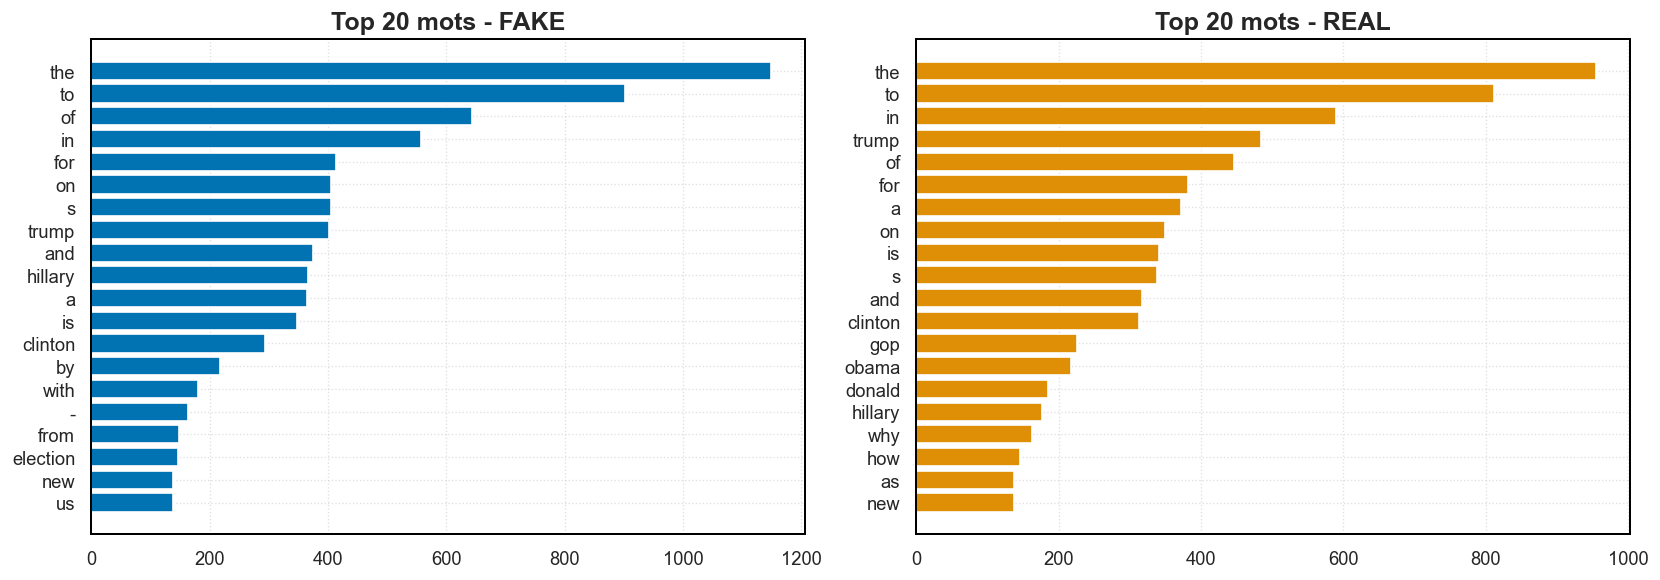

In [41]:
tokens_fake_flat = df_eda_fake["text"].str.lower().str.cat(sep=" ").split()
tokens_real_flat = df_eda_real["text"].str.lower().str.cat(sep=" ").split()

counter_fake = Counter(tokens_fake_flat)
counter_real = Counter(tokens_real_flat)

top20_fake = counter_fake.most_common(20)
top20_real = counter_real.most_common(20)

words_fake, counts_fake = zip(*top20_fake)
words_real, counts_real = zip(*top20_real)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(words_fake, counts_fake, color=PALETTE[0])
axes[0].set_title("Top 20 mots - FAKE")
axes[0].invert_yaxis()

axes[1].barh(words_real, counts_real, color=PALETTE[1])
axes[1].set_title("Top 20 mots - REAL")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig((FIGURE_DIR / "04_tokens_distribution_per_labels.png").as_posix())
plt.show()

In [42]:
unique_tokens_fake = set(tokens_fake_flat)
unique_tokens_real = set(tokens_real_flat)

unique_tokens_union = unique_tokens_fake | unique_tokens_real
unique_tokens_intersection = unique_tokens_fake & unique_tokens_real
unique_tokens_fake_without_intersection = (
    unique_tokens_fake - unique_tokens_intersection
)
unique_tokens_real_without_intersection = (
    unique_tokens_real - unique_tokens_intersection
)


print(f"Nombre total de tokens : {len(unique_tokens_union)}")
print(f"Nombre de tokens communs : {len(unique_tokens_intersection)}")
print(
    f"Nombre de tokens uniquement dans les titres FAKE : {len(unique_tokens_fake_without_intersection)}"
)
print(
    f"Nombre de tokens uniquement dans les titres REAL : {len(unique_tokens_real_without_intersection)}"
)

counter_fake_unique = deepcopy(counter_fake)
counter_real_unique = deepcopy(counter_real)
for token in list(unique_tokens_intersection):
    counter_fake_unique.pop(token)
    counter_real_unique.pop(token)

top10_fake_unique = counter_fake_unique.most_common(10)
top10_real_unique = counter_real_unique.most_common(10)

words_fake_unique, counts_fake_unique = zip(*top10_fake_unique)
words_real_unique, counts_real_unique = zip(*top10_real_unique)

print()
print(
    "Liste des 10 tokens uniquement présent dans les titres FAKE les plus communs :\n",
    words_fake_unique,
)

print()
print(
    "Liste de 10 tokens uniquement présent dans les titres REAL les plus communs :\n",
    words_real_unique,
)


Nombre total de tokens : 13492
Nombre de tokens communs : 3109
Nombre de tokens uniquement dans les titres FAKE : 6164
Nombre de tokens uniquement dans les titres REAL : 4219

Liste des 10 tokens uniquement présent dans les titres FAKE les plus communs :
 ('(video)', 're:', 'truthfeed', 'breaking:', 'finest', '[video]', 'gold', 'podesta', 'fraud', 'aleppo')

Liste de 10 tokens uniquement présent dans les titres REAL les plus communs :
 ('(+video)', 'jeb', 'marriage', 'rand', 'convention', 'bid', 'hampshire', 'polarization', 'boehner', 'takeaways')


In [43]:
uncertain_words = {"could", "might", "reportedly", "claims", "allegedly"}


def is_ambiguous(title: str) -> bool:
    words = set(title.lower().split())
    return len(words & uncertain_words) > 0 and len(words) < 15


df_eda["is_ambiguous"] = df_eda["text"].apply(is_ambiguous)
ambiguous_titles = df_eda[df_eda["is_ambiguous"]][["text", "label"]]

print("Titres ambigus :")
print(
    f"  Texte : {ambiguous_titles.loc[273, 'text']} | label : {ambiguous_titles.loc[273, 'label']}"
)
print(
    f"  Texte : {ambiguous_titles.loc[974, 'text']} | label : {ambiguous_titles.loc[447, 'label']}"
)
print(
    f"  Texte : {ambiguous_titles.loc[498, 'text']} | label : {ambiguous_titles.loc[463, 'label']}"
)

Titres ambigus :
  Texte : Yes, Ted Cruz could win | label : 1
  Texte : The Sex Scandal That Could Change The Election | label : 0
  Texte : A report said Trump's donations to vets might be shady. His response was predictable. | label : 0


Les titres ambigus posent problème parce qu’ils ne ressemblent ni clairement à des titres FAKE ni à des titres REAL. Ils peuvent mélanger des éléments crédibles avec des formulations floues, ou encore des champs lexicaux opposés. Ces titres ambigus diminuent la séparabilité des classes.

## Partie 2 — Nettoyage et prétraitement

### 2.1 Pipeline de nettoyage

In [44]:
nlp = spacy.load("en_core_web_sm")

stop_words = set(nltk.corpus.stopwords.words("english"))
negations = {"not", "no", "never", "neither"}
stop_words = stop_words - negations

contractions = {
    "don't": "do not",
    "doesn't": "does not",
    "didn't": "did not",
    "can't": "can not",
    "couldn't": "could not",
    "won't": "will not",
    "wouldn't": "would not",
    "shouldn't": "should not",
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "haven't": "have not",
    "hasn't": "has not",
    "hadn't": "had not",
    "i'm": "i am",
    "you're": "you are",
    "he's": "he is",
    "she's": "she is",
    "it's": "it is",
    "we're": "we are",
    "they're": "they are",
    "i've": "i have",
    "you've": "you have",
    "we've": "we have",
    "they've": "they have",
    "i'll": "i will",
    "you'll": "you will",
    "he'll": "he will",
    "she'll": "she will",
    "we'll": "we will",
    "they'll": "they will",
    "there's": "there is",
    "that's": "that is",
}

DOMAIN_PATTERN = re.compile(
    r"\b(?:[a-z0-9-]+\.)+(?:org|net|info|co|io|gov|edu|uk|us|biz|online|site)\b"
)

TLD_PATTERN = re.compile(r"\.(com|org|net|info|co|io|gov|edu|uk|us|biz|online|site)\b")

CONTRACTION_PATTERN = re.compile(
    r"\b(" + "|".join(map(re.escape, contractions.keys())) + r")\b"
)


def expand_contractions(text: str) -> str:
    return CONTRACTION_PATTERN.sub(lambda x: contractions[x.group()], text)


def clean_title(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = DOMAIN_PATTERN.sub("", text)
    text = TLD_PATTERN.sub("", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\b\d+\b", "", text)
    text = expand_contractions(text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    doc = nlp(" ".join(tokens))
    lemmas = [token.lemma_ for token in doc]
    lemmas = [w for w in lemmas if len(w) >= 2]
    return " ".join(lemmas)


df["text_cleaned"] = df["text"].apply(clean_title)
df.head()

,text,label,text_cleaned
0,You Can Smell Hillary s Fear,0,smell hillary fear
1,Watch The Exact Moment Paul Ryan Committed Pol...,0,watch exact moment paul ryan commit political ...
2,Kerry to go to Paris in gesture of sympathy,1,kerry go paris gesture sympathy
3,Bernie supporters on Twitter erupt in anger ag...,0,bernie supporter twitter erupt anger dnc try warn
4,The Battle of New York: Why This Primary Matters,1,battle new york primary matter


On ne supprime pas les mots "not", "no", "never", "neither" car ils servent à indiquer le caractère négatif d'une phrase.

### 2.2 Mesure de l'impact du nettoyage

In [45]:
df_eda["text_cleaned"] = df["text_cleaned"]
df_eda["tokens_cleaned"] = df_eda["text_cleaned"].str.split()
df_eda["length_cleaned"] = df_eda["tokens_cleaned"].apply(
    lambda list_tokens: len(list_tokens)
)

In [46]:
tokens_flat = df_eda["text"].str.lower().str.cat(sep=" ").split()
tokens_cleaned_flat = df_eda["text_cleaned"].str.lower().str.cat(sep=" ").split()

counter = Counter(tokens_flat)
counter_cleaned = Counter(tokens_cleaned_flat)

print(f"Nombre de tokens avant nettoyage : {len(counter)}")
print(f"Nombre de tokens après nettoyage : {len(counter_cleaned)}")
print(
    f"Différence du nombre de tokens avant et après nettoyage : {len(counter) - len(counter_cleaned)}"
)

Nombre de tokens avant nettoyage : 13492
Nombre de tokens après nettoyage : 7811
Différence du nombre de tokens avant et après nettoyage : 5681


In [47]:
length = df_eda["length"]
length_cleaned = df_eda["length_cleaned"]
length_difference = length - length_cleaned

print(
    f"Nombre moyenne de tokens par titre avant nettoyage : {length.mean():.2f} (+/- {length.std():.2f})"
)
print(
    f"Nombre moyenne de tokens par titre après nettoyage : {length_cleaned.mean():.2f} (+/- {length_cleaned.std():.2f})"
)
print(
    f"Réduction moyenne du nombre de token par titre : {length_difference.mean():.2f} (+/- {length_difference.std():.2f})"
)

Nombre moyenne de tokens par titre avant nettoyage : 10.62 (+/- 4.05)
Nombre moyenne de tokens par titre après nettoyage : 7.36 (+/- 2.66)
Réduction moyenne du nombre de token par titre : 3.25 (+/- 2.34)


In [48]:
mask = (
    (df["text_cleaned"].str.strip() != "")
    & (df["text_cleaned"].str.strip().str.lower() != "null")
    & (df["text_cleaned"].str.strip().str.lower() != "none")
    & (df["text_cleaned"] is not None)
)

print(f"Nombre de ligne vide : {len(df[~mask])}")

print()
print(df[~mask].head())
df_cleaned = df[mask]

Nombre de ligne vide : 2

              text  label text_cleaned
3456             :      0             
6037  C          !      0             


Je supprime la ligne vide après nettoyage. Cette ligne n'apporte pas d'information.

Pourquoi la conservation des mots de négation est-elle particulièrement importante dans un contexte de détection de désinformation ? Donnez deux exemples concrets tirés du corpus.

* Il est crutial de conserver les mots de négation car il change le sens de la phrase. "Brexit Encourages UK to Trade With Non-EU States, Including Russia" et "Brexit Does Not Encourages UK to Trade With Non-EU States, Including Russia" sont en opposition.

* De plus ils peuvent indiquer une constation. Par exemple dans la phrase "Donald Trump Is Changing His Campaign Slogan to Prove He’s Not Racist", la négation montre que Donald Trump contest l'idée qu'il soit raciste.

## Partie 3 — Représentation vectorielle

### 3.1 Vectorisation TF-IDF

In [49]:
texts = df_cleaned[["text", "text_cleaned"]]
labels = df_cleaned["label"]

texts_train, texts_test, labels_train, labels_test = train_test_split(
    texts, labels, stratify=labels, test_size=0.2, random_state=RANDOM_STATE
)

texts_train_cleaned = texts_train["text_cleaned"]
texts_test_cleaned = texts_test["text_cleaned"]

texts_train_raw = tf.convert_to_tensor(texts_train["text"])
texts_test_raw = tf.convert_to_tensor(texts_test["text"])

print(f"Nombre total de titres : {len(texts)}")
print(
    f"Nombre total de titres dans le jeu d'entrainement : {len(texts_train)} ({len(texts_train) / len(texts) * 100:.0f}%)"
)
print(
    f"Nombre total de titres dans le jeu de test : {len(texts_test)} ({len(texts_test) / len(texts) * 100:.0f}%)"
)

print()
print(
    f"Répartition des labels dans le jeu de données : FAKE {(1 - labels.sum() / len(labels)) * 100:.0f}% - REAL {labels.sum() / len(labels) * 100:.0f}%"
)
print(
    f"Répartition des labels dans le jeu d'entrainement : FAKE {(1 - labels_train.sum() / len(labels_train)) * 100:.0f}% - REAL {labels_train.sum() / len(labels_train) * 100:.0f}%"
)
print(
    f"Répartition des labels dans le jeu de test : FAKE {(1 - labels_test.sum() / len(labels_test)) * 100:.0f}% - REAL {labels_test.sum() / len(labels_test) * 100:.0f}%"
)

Nombre total de titres : 6333
Nombre total de titres dans le jeu d'entrainement : 5066 (80%)
Nombre total de titres dans le jeu de test : 1267 (20%)

Répartition des labels dans le jeu de données : FAKE 50% - REAL 50%
Répartition des labels dans le jeu d'entrainement : FAKE 50% - REAL 50%
Répartition des labels dans le jeu de test : FAKE 50% - REAL 50%


In [50]:
MAX_FEATURES = 3000

tfidf = TfidfVectorizer(
    max_features=MAX_FEATURES,
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2),
    sublinear_tf=True,
)

texts_train_vectorized = tfidf.fit_transform(texts_train_cleaned, labels_train)
texts_test_vectorized = tfidf.transform(texts_test_cleaned)

print(f"Vocabulaire : {len(tfidf.get_feature_names_out())} mots uniques")

Vocabulaire : 3000 mots uniques


In [51]:
joblib.dump(tfidf, TF_IDF_VECTORIZER_FILE.as_posix())
print(f"Vectorizer enregistré : path={TF_IDF_VECTORIZER_FILE}")

Vectorizer enregistré : path=C:\Users\Administrateur\Documents\DESSAUX_Damien_ECF4\models\tf_idf_vectorizer.pkl


### 3.2 Embedding avec TensorFlow

In [52]:
MAX_TOKENS = 5000
OUTPUT_SEQUENCE_LENGTH = 30

vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    ngrams=(1, 2),
    output_mode="int",
    output_sequence_length=OUTPUT_SEQUENCE_LENGTH,
    standardize="lower_and_strip_punctuation",
    split="whitespace",
)

vectorizer.adapt(texts_train_raw)

texts_train_seq = vectorizer(texts_train_raw)
texts_test_seq = vectorizer(texts_test_raw)

print(f"Dimensions de texts_train_seq: {texts_train_seq.shape}")
print(f"Dimensions de texts_test_seq: {texts_test_seq.shape}")
print(f"Vocabulaire : {len(vectorizer.get_vocabulary())} mots uniques")

Dimensions de texts_train_seq: (5066, 30)
Dimensions de texts_test_seq: (1267, 30)
Vocabulaire : 5000 mots uniques


Quelle différence fondamentale y a-t-il entre un vecteur TF-IDF et un vecteur d'embedding appris ? Laquelle de ces deux représentations est capable de capturer que `misleading` et `deceptive` sont sémantiquement proches ? Justifiez.

* TF-IDF encode uniquement la présence d'un mot et ne contient aucune information de similarité sémantique entre les mots. Les mots "misleading" et "deceptive" sont des dimensions indépendantes, même s'ils sont synonymes.

* Les vecteurs embeddings sont appris à partir des contextes d'apparition des mots. Des mots apparaissant dans des contextes similaires ont des vecteurs proches. Ainsi, "misleading" et "deceptive" deviennent proches dans l’espace vectoriel si leurs contextes d’usage est proche.

In [53]:
label_encoder = LabelEncoder()
labels_train_encoded = label_encoder.fit_transform(labels_train)
labels_test_encoded = label_encoder.transform(labels_test)

## Partie 4 — Modélisation

### 4.1 Modèle baseline — réseau dense sur TF-IDF

In [54]:
def create_model_dense() -> keras.Sequential:
    model = keras.Sequential(
        [
            layers.Input(shape=(MAX_FEATURES,), name="input"),
            layers.Dense(256, activation="relu", name="hidden1"),
            layers.Dropout(0.4, name="dropout1"),
            layers.Dense(128, activation="relu", name="hidden2"),
            layers.Dropout(0.3, name="dropout2"),
            layers.Dense(1, activation="sigmoid", name="output"),
        ],
        name="dense",
    )

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

    return model


model_dense = create_model_dense()
model_dense.summary()

Model: "dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1 (Dense)                 │ (None, 256)            │       768,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 801,281 (3.06 MB)

 Trainable params: 801,281 (3.06 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
def create_early_stopping():
    return keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    )


def create_reduce_lr_on_plateau():
    return keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    )


def create_model_checkpoint(filepath: Path):
    return keras.callbacks.ModelCheckpoint(
        filepath=filepath.as_posix(),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1,
    )


start_fit_model_dense = time.time()
history_model_dense = model_dense.fit(
    texts_train_vectorized,
    labels_train_encoded,
    batch_size=64,
    epochs=30,
    validation_split=0.15,
    callbacks=[
        create_reduce_lr_on_plateau(),
        create_early_stopping(),
        create_model_checkpoint(MODEL_DENSE_FILE),
    ],
    verbose=1,
)
end_fit_model_dense = time.time()

Epoch 1/30
55/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5782 - loss: 0.6868
Epoch 1: val_accuracy improved from None to 0.77237, saving model to C:/Users/Administrateur/Documents/DESSAUX_Damien_ECF4/models/model_dense.keras

Epoch 1: finished saving model to C:/Users/Administrateur/Documents/DESSAUX_Damien_ECF4/models/model_dense.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6763 - loss: 0.6511 - val_accuracy: 0.7724 - val_loss: 0.5343 - learning_rate: 0.0010
Epoch 2/30
53/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8248 - loss: 0.4250
Epoch 2: val_accuracy improved from 0.77237 to 0.80000, saving model to C:/Users/Administrateur/Documents/DESSAUX_Damien_ECF4/models/model_dense.keras

Epoch 2: finished saving model to C:/Users/Administrateur/Documents/DESSAUX_Damien_ECF4/models/model_dense.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8460 - loss: 0.3603 - val_accuracy: 0.8000 - val_loss: 0.4839 - learning_rate: 0.0010
Epoch 3/30
52/68 ━━━━━━━━━━

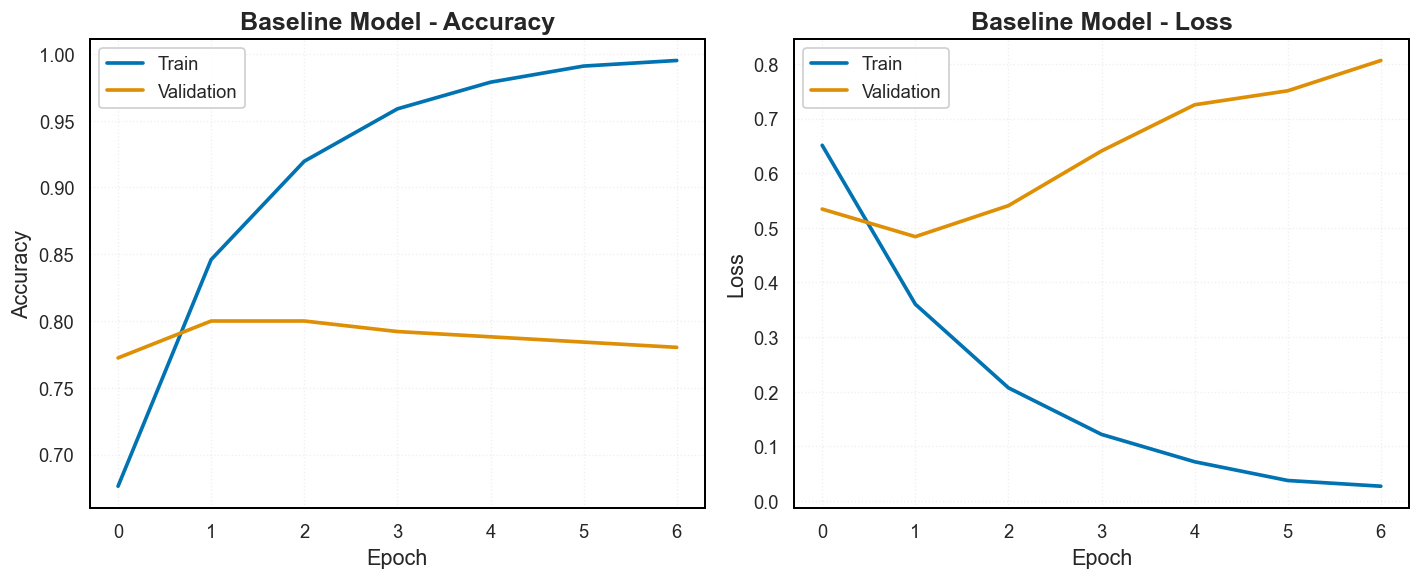

In [56]:
def plot_history(history, model_name: str, savepath: Path) -> None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Accuracy
    ax1.plot(history.history["accuracy"], label="Train")
    ax1.plot(history.history["val_accuracy"], label="Validation")
    ax1.set_title(f"{model_name} - Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Loss
    ax2.plot(history.history["loss"], label="Train")
    ax2.plot(history.history["val_loss"], label="Validation")
    ax2.set_title(f"{model_name} - Loss")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(savepath.as_posix())
    plt.show()


plot_history(
    history_model_dense,
    "Baseline Model",
    FIGURE_DIR / "05_history_model_dense.png",
)

Les courbes de loss et d'accuracy montre que le modèle sur-apprends.

### 4.2 Modèle avec embeddings appris — architecture séquentielle

In [57]:
def create_model_bidirectional_lstm(
    vectorizer: tf.keras.layers.TextVectorization,
) -> keras.Sequential:
    vocab_size = len(vectorizer.get_vocabulary())

    model = keras.Sequential(
        [
            keras.Input(shape=(1,), dtype=tf.string),
            vectorizer,
            layers.Embedding(input_dim=vocab_size, output_dim=64, mask_zero=True),
            layers.Bidirectional(layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
            layers.Dense(64, activation="relu"),
            layers.Dropout(0.3),
            layers.Dense(1, activation="sigmoid"),
        ]
    )

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

    return model


model_bidirectional_lstm = create_model_bidirectional_lstm(vectorizer)
model_bidirectional_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, 30)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 30, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 394,369 (1.50 MB)

 Trainable params: 394,369 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

In [58]:
start_fit_model_bidirectional_lstm = time.time()
history_model_bidirectional_lstm = model_bidirectional_lstm.fit(
    texts_train_raw,
    labels_train_encoded,
    batch_size=64,
    epochs=30,
    validation_split=0.15,
    callbacks=[
        create_reduce_lr_on_plateau(),
        create_early_stopping(),
        create_model_checkpoint(MODEL_BIDIRECTIONAL_LSTM_FILE),
    ],
    verbose=1,
)
end_fit_model_bidirectional_lstm = time.time()

Epoch 1/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5582 - loss: 0.6790
Epoch 1: val_accuracy improved from None to 0.77895, saving model to C:/Users/Administrateur/Documents/DESSAUX_Damien_ECF4/models/model_bidirectional_lstm.keras

Epoch 1: finished saving model to C:/Users/Administrateur/Documents/DESSAUX_Damien_ECF4/models/model_bidirectional_lstm.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.6303 - loss: 0.6368 - val_accuracy: 0.7789 - val_loss: 0.4814 - learning_rate: 0.0010
Epoch 2/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8221 - loss: 0.4121
Epoch 2: val_accuracy improved from 0.77895 to 0.82105, saving model to C:/Users/Administrateur/Documents/DESSAUX_Damien_ECF4/models/model_bidirectional_lstm.keras

Epoch 2: finished saving model to C:/Users/Administrateur/Documents/DESSAUX_Damien_ECF4/models/model_bidirectional_lstm.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8479 - loss: 0.3583 - val_accuracy: 0.8211 - val_loss: 0.

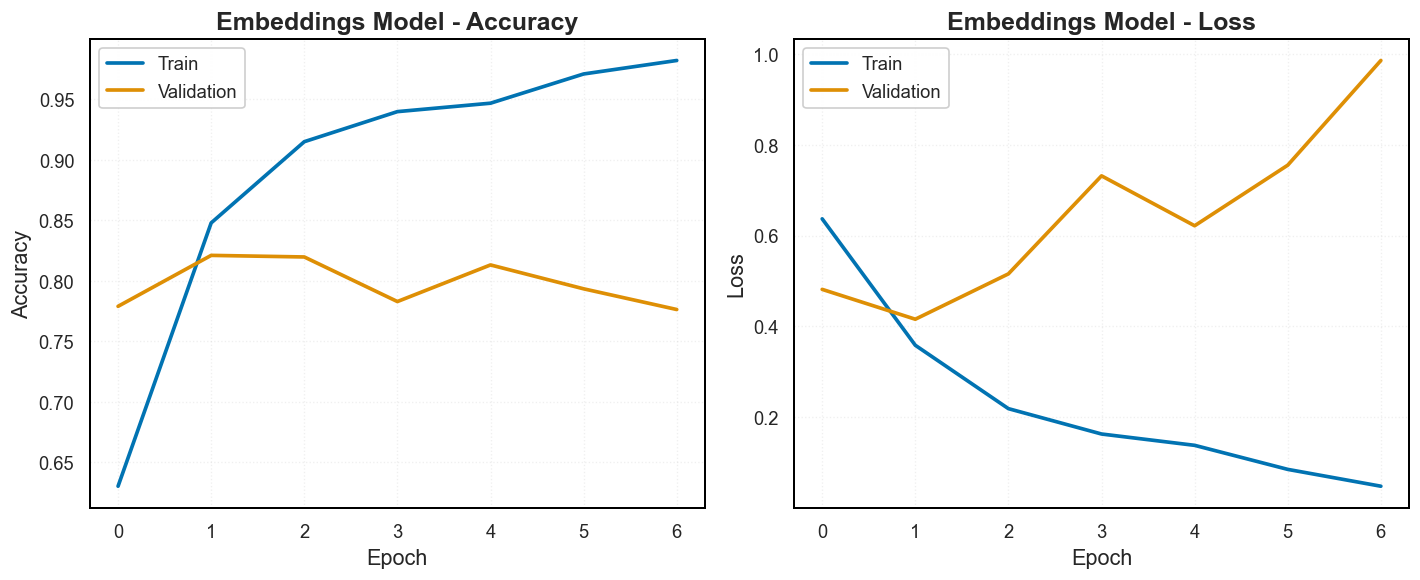

In [59]:
plot_history(
    history_model_bidirectional_lstm,
    "Embeddings Model",
    FIGURE_DIR / "06_history_model_bidirectional_lstm.png",
)

Les courbes de loss et d'accuracy montre que le modèle sur-apprends.

### 4.3 Comparaison des deux architectures

In [ ]:
def predict_with_timing(model, X, y, threshold=0.5):
    start_time = time.time()
    y_proba = model.predict(X)
    end_time = time.time()

    y_pred = (y_proba > threshold).astype(int)

    inference_time_per_sample = (end_time - start_time) / len(y)

    return {
        "y_proba": y_proba,
        "y_pred": y_pred,
        "inference_time": inference_time_per_sample,
    }


def compute_classification_metrics(y_true, y_pred):
    return {
        "Accuracy (test)": accuracy_score(y_true, y_pred),
        "Precision - classe FAKE": precision_score(y_true, y_pred, pos_label=0),
        "Recall - classe FAKE": recall_score(y_true, y_pred, pos_label=0),
        "Precision - classe REAL": precision_score(y_true, y_pred, pos_label=1),
        "Recall - classe REAL": recall_score(y_true, y_pred, pos_label=1),
        "F1-score (macro)": f1_score(y_true, y_pred, average="macro"),
        "AUC-ROC": roc_auc_score(y_true, y_pred),
    }


def get_model_info(model, history, train_time):
    return {
        "Epochs effectifs (EarlyStopping)": len(history.epoch),
        "Nombre de paramètres entraînables": sum(
            tf.keras.backend.count_params(w) for w in model.trainable_weights
        ),
        "Temps d'entraînement (approx.)": train_time,
    }


def compare_models(models_config, y_true):
    """
    models_config: liste de dicts contenant:
        {
            "name": str,
            "model": keras model,
            "X_test": données de test,
            "history": history object,
            "train_time": float
        }
    """

    results = {}

    for config in models_config:
        name = config["name"]
        model = config["model"]
        X_test = config["X_test"]
        history = config["history"]
        train_time = config["train_time"]

        pred_results = predict_with_timing(model, X_test, y_true)

        metrics = compute_classification_metrics(y_true, pred_results["y_pred"])

        model_info = get_model_info(model, history, train_time)

        results[name] = {
            **metrics,
            **model_info,
            "Temps d'inférence (approx.)": pred_results["inference_time"],
        }

    df = pd.DataFrame(results)
    df.insert(0, "Critère", df.index)

    return df.reset_index(drop=True)


models_config = [
    {
        "name": "Modèle Dense (TF-IDF)",
        "model": model_dense,
        "X_test": texts_test_vectorized,
        "history": history_model_dense,
        "train_time": end_fit_model_dense - start_fit_model_dense,
    },
    {
        "name": "Modèle LSTM Bidirectionnel (Embeddings)",
        "model": model_bidirectional_lstm,
        "X_test": texts_test_raw,
        "history": history_model_bidirectional_lstm,
        "train_time": end_fit_model_bidirectional_lstm
        - start_fit_model_bidirectional_lstm,
    },
]

df_models = compare_models(models_config, labels_test)
df_models.head(10)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


,Critère,Modèle Dense (TF-IDF),Modèle LSTM Bidirectionnel (Embeddings)
0,Accuracy (test),0.799526,0.799526
1,Precision - classe FAKE,0.768034,0.794712
2,Recall - classe FAKE,0.857820,0.807267
3,Precision - classe REAL,0.839286,0.804487
4,Recall - classe REAL,0.741325,0.791798
5,F1-score (macro),0.798859,0.799516
6,AUC-ROC,0.799572,0.799533
7,Epochs effectifs (EarlyStopping),7.000000,7.000000
8,Nombre de paramètres entraînables,801281.000000,394369.000000
9,Temps d'entraînement (approx.),3.087110,12.180476


Lequel des deux modèles recommanderiez-vous pour une mise en production ? Justifiez votre choix en tenant compte à la fois des performances et des contraintes opérationnelles (temps de réponse, maintenance, volume de données).

* Les deux modèles présentent de l'overfitting. Bien que le modèle Dense présente un meilleur recall et que le modèle LSTM Bidirectionnel présente une meilleur précission, l'accuracy, le F1-score et l'AUC-ROC sont très proches. L'objectif ici est de classer correctement l'ensemble des articles, on s'oriente donc vers une métrique globale comme le F1-score. Si on cherchait à réduire les faux-positifs, c'est à dire les titres qui sont classé comme REAL alors qu'il sont FAKE, on s'orienterait vers un modèle avec une bonne precission. Les deux modèles ayant un F1-score proche, on choisit comme second critère la précission de la classe REAL. Le modèle recommandé est le modèle Dense. De plus le temps d'entrainement est plus court pour ce modèle que pour le modèle LSMT Bidirectionnel.

## Partie 5 — Évaluation approfondie

### 5.1 Analyse des performances du meilleur modèle

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


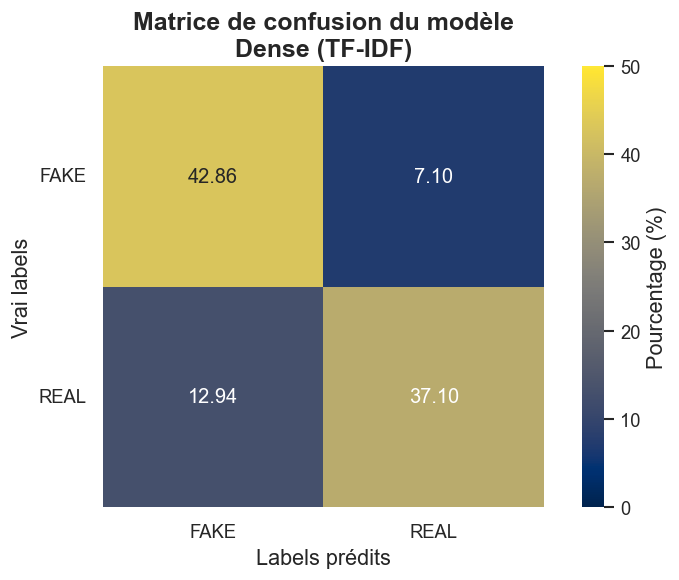

In [90]:
labels_names = ["FAKE", "REAL"]

predict_dense = predict_with_timing(model_dense, texts_test_vectorized, labels_test)
labels_pred_dense = predict_dense["y_pred"]
labels_proba_dense = predict_dense["y_proba"]

cm = confusion_matrix(labels_test, labels_pred_dense)
cm_percent = cm / cm.sum().sum() * 100

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".2f",
    cmap="cividis",
    square=True,
    vmin=0,
    vmax=50,
    cbar_kws={"label": "Pourcentage (%)"},
)

plt.xlabel("Labels prédits")
plt.xticks(np.arange(0.5, 2.5, 1), labels_names, rotation=0)
plt.ylabel("Vrai labels")
plt.yticks(np.arange(0.5, 2.5, 1), labels_names, rotation=0)
plt.title("Matrice de confusion du modèle\nDense (TF-IDF)")

plt.tight_layout()
plt.savefig((FIGURE_DIR / "07_confusion_matrix_model_dense").as_posix())
plt.show()

* Environ 86% des titres FAKE ont été bien classés, soit environ 14% de faux-positifs.
* Environ 74% des titres REAL ont été bien classés, soit envriron 26% de faux-négatifs.

In [63]:
print("Rapport de classification du modèle Dense :")
print(classification_report(labels_test, labels_pred_dense))

Rapport de classification du modèle Dense :
              precision    recall  f1-score   support

           0       0.77      0.86      0.81       633
           1       0.84      0.74      0.79       634

    accuracy                           0.80      1267
   macro avg       0.80      0.80      0.80      1267
weighted avg       0.80      0.80      0.80      1267



* Les classes étant équilibrées, les métriques accuracy ($\simeq 0.80$) et f1-score macro ($\simeq 0.80$) ne sont pas biaisées et montre que le modèle a une performance globale correcte.
* Le modèle détecte bien la classe FAKE (recall $\simeq 0.86$), mais a tendance à prédire cette classe à tord (precision $\simeq 0.77$).
* Le modèle détecte moins bien la classe REAL (recall $\simeq 0.74$) et ses prédiction pour cette classe sont plus fiables (precision $\simeq 0.86$).
* En conclusion, le modèle est correct mais il détecte mieux les titres FAKE que les titres REAL, la modification du seuil de décision pourrait corriger ce déséquilibre de prédiction.

In [79]:
fpr, tpr, thresholds = roc_curve(labels_test, labels_proba_dense)
auc = roc_auc_score(labels_test, labels_proba_dense)

print(f"AUC : {auc}")

AUC : 0.8858335700509815


In [80]:
youden_j = tpr - fpr
optimal_idx = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_idx]

print("Seuil optimal : ", optimal_threshold)

Seuil optimal :  0.41724616289138794


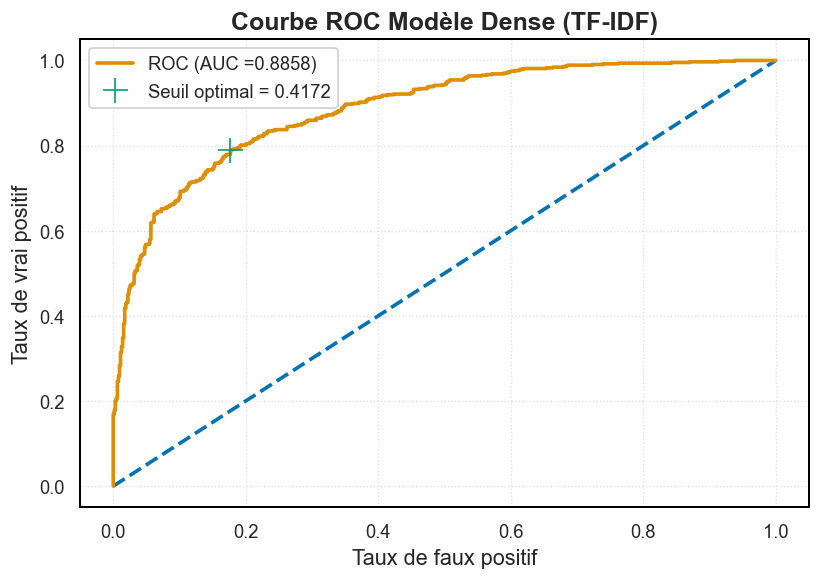

In [99]:
fig, axes = plt.subplots(1, 1, figsize=(7, 5))

axes.plot([0, 1], [0, 1], "--", color=PALETTE[0])
axes.plot(fpr, tpr, label=f"ROC (AUC ={auc:.4f})", color=PALETTE[1])
axes.plot(
    fpr[optimal_idx],
    tpr[optimal_idx],
    "+",
    markersize=15,
    label=f"Seuil optimal = {optimal_threshold:.4f}",
    color=PALETTE[2],
)

axes.set_title("Courbe ROC Modèle Dense (TF-IDF)")
axes.set_xlabel("Taux de faux positif")
axes.set_ylabel("Taux de vrai positif")
axes.legend()

plt.tight_layout()
plt.savefig((FIGURE_DIR / "08_roc_curve_model_dense").as_posix())
plt.show()

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


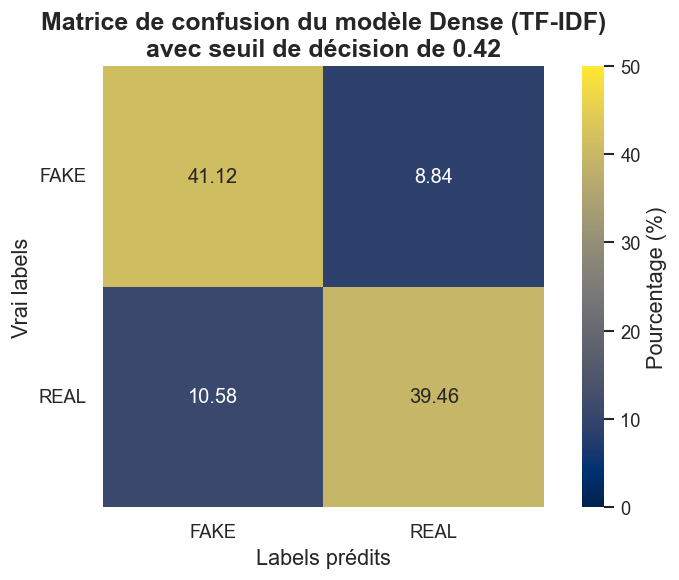

In [100]:
predict_dense_optimal_threshold = predict_with_timing(
    model_dense, texts_test_vectorized, labels_test, threshold=optimal_threshold
)
labels_pred_dense_optimal_threshold = predict_dense_optimal_threshold["y_pred"]

cm_optimal_threshold = confusion_matrix(
    labels_test, labels_pred_dense_optimal_threshold
)
cm_percent_optimal_threshold = (
    cm_optimal_threshold / cm_optimal_threshold.sum().sum() * 100
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_percent_optimal_threshold,
    annot=True,
    fmt=".2f",
    cmap="cividis",
    square=True,
    vmin=0,
    vmax=50,
    cbar_kws={"label": "Pourcentage (%)"},
)

plt.xlabel("Labels prédits")
plt.xticks(np.arange(0.5, 2.5, 1), labels_names, rotation=0)
plt.ylabel("Vrai labels")
plt.yticks(np.arange(0.5, 2.5, 1), labels_names, rotation=0)
plt.title(
    f"Matrice de confusion du modèle Dense (TF-IDF)\navec seuil de décision de {optimal_threshold:.2f}"
)

plt.tight_layout()
plt.savefig(
    (FIGURE_DIR / "09_confusion_matrix_model_dense_optimal_threshold").as_posix()
)
plt.show()

Avec un seuil de décision de $\simeq 0.42$, le détection des classes FAKE et REAL s'équilibre autoure de $\simeq 40%$.

In [ ]:
print(
    f"Rapport de classification du modèle Dense avec seuil de décision de {optimal_threshold} :"
)
print(classification_report(labels_test, labels_pred_dense_optimal_threshold))

Rapport de classification du modèle Dense avec seuil de décision de 0.41724616289138794 :
              precision    recall  f1-score   support

           0       0.80      0.82      0.81       633
           1       0.82      0.79      0.80       634

    accuracy                           0.81      1267
   macro avg       0.81      0.81      0.81      1267
weighted avg       0.81      0.81      0.81      1267



* La modification du seuil de décision a permis d'avoir un modèle globalement meilleur, gain de 0.01 en accuracy et f1-score macro.
* Le modèle détecte moins bien la classe FAKE (-0.04 recall) mais les titres classés comme FAKE ont une plus grande probabilité d'être vraiment FAKE (+0.03 precision).
* A l'inverse le modèle détecte mieux la classe REAL (+0.05 recall) mais les titres classés comme REAL ont une moins grande probabilité d'être vraiement REAL (-0.02 precision).
* L'objectif étant de classer au mieux l'ensemble des articles, on recommande d'utiliser le seuil de décision optimal.